In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import psycopg
import psycopg.sql as sql


from dotenv import load_dotenv
load_dotenv()

True

Number of pronghorn: 1093
Number of images with pronghorn: 457
Number of crops with pronghorn: 600
Total number of images in survey: 5722
Proportion of images with pronghorn: 0.0799
Proportion of image pixels that are in pronghorn crops: 0.010176


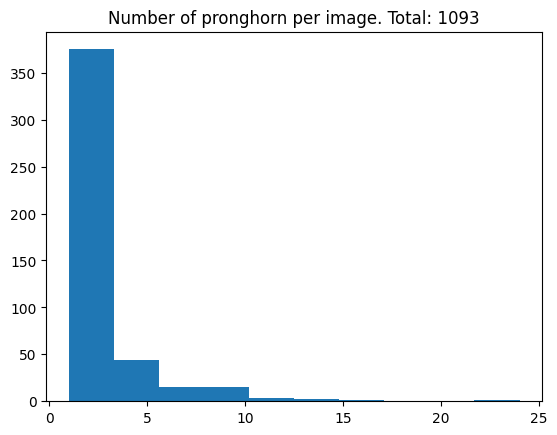

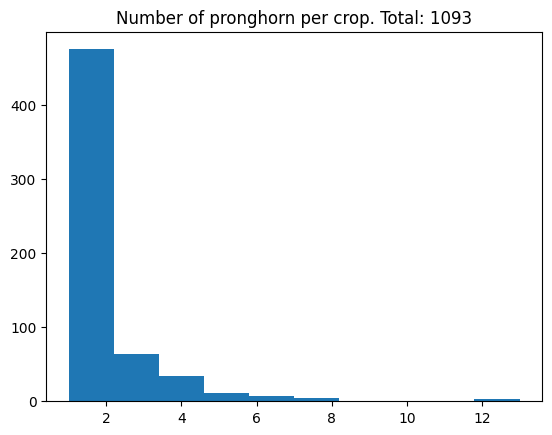

In [ ]:
password = os.getenv("DB_PASSWORD")

with psycopg.connect(f"dbname=pronghorn_count_new user=pronghorn_count password={password} host=datagaze.arcc.uwyo.edu port=5433") as conn:
    with conn.cursor() as cur:
        # cur.row_factory = psycopg.rows.dict_row
        num_images_survey = cur.execute("""SELECT COUNT(*) FROM core.images WHERE survey_id = 1""").fetchone()[0]
        
        # Get number of pronghorn in each image
        ph_in_im = cur.execute("""SELECT image_id, COUNT(*) AS pronghorn_count
                                  FROM core.annotations 
                                  WHERE label_id = 2
                                  GROUP BY image_id
                                """).fetchall()
        # Get number of pronghorn in each annotation crop
        ph_in_crop = cur.execute("""SELECT reviewed_area_id, COUNT(*) FROM core.annotations as A
                                    JOIN core.annotations_reviewed_area as RA 
                                    ON A.annotation_id = RA.annotation_id
                                    WHERE label_id = 2
                                    GROUP BY reviewed_area_id
                                    ORDER BY reviewed_area_id ASC
                                 """).fetchall()

ph_in_im = np.array(ph_in_im)
plt.hist(ph_in_im[:, 1])
plt.title(f"Number of pronghorn per image. Total: {np.sum(ph_in_im[:, 1])}")

plt.figure()
ph_in_crop = np.array(ph_in_crop)
plt.hist(ph_in_crop[:, 1])
plt.title(f"Number of pronghorn per crop. Total: {np.sum(ph_in_crop[:, 1])}")

num_ph = np.sum(ph_in_im[:, 1])
num_ph_images = len(ph_in_im)
num_ph_crops = len(ph_in_crop)
print(f"Number of pronghorn: {num_ph}")
print(f"Number of images with pronghorn: {num_ph_images}")
print(f"Number of crops with pronghorn: {num_ph_crops}")
print(f"Total number of images in survey: {num_images_survey}")
print(f"Proportion of images with pronghorn: {num_ph_images/num_images_survey:.4f}")

crop_pixels = 2100 * 2100 # H x W
image_pixels = 5504 * 8256 # H x W

prop_crop_pixels = num_ph_crops * crop_pixels / (num_images_survey * image_pixels)
print(f"Proportion of image pixels that are in pronghorn crops: {prop_crop_pixels:.6f}")

In [6]:
with psycopg.connect(f"dbname=pronghorn_count_new user=pronghorn_count password={password} host=datagaze.arcc.uwyo.edu port=5433") as conn:
    with conn.cursor() as cur:
        # cur.row_factory = psycopg.rows.dict_row
        
        ph_in_im = cur.execute("""SELECT COUNT(*) AS pronghorn_count
                                  FROM core.annotations 
                                  WHERE label_id = 2
                                  GROUP BY image_id
                                """).fetchall()